In [1]:
import os
import pandas as pd

In [2]:
parent_dir = R"C:\Users\silve\Documents\210\data"

for dir_path, _, files in os.walk(parent_dir):
    file_count = len([entry for entry in files if os.path.isfile(os.path.join(dir_path, entry))])
    
    print(f"Directory: {dir_path}, Files: {file_count}")

Directory: C:\Users\silve\Documents\210\data, Files: 0
Directory: C:\Users\silve\Documents\210\data\Cropped-png-EXP-20-BV6126 AST FISH 201116, Files: 0
Directory: C:\Users\silve\Documents\210\data\Cropped-png-EXP-20-BV6126 AST FISH 201116\debug, Files: 180
Directory: C:\Users\silve\Documents\210\data\Cropped-png-EXP-20-BV6126 AST FISH 201116\Pos101, Files: 0
Directory: C:\Users\silve\Documents\210\data\Cropped-png-EXP-20-BV6126 AST FISH 201116\Pos101\trap-16_id-43-16, Files: 39
Directory: C:\Users\silve\Documents\210\data\Cropped-png-EXP-20-BV6126 AST FISH 201116\Pos101\trap-30_id-43-08, Files: 39
Directory: C:\Users\silve\Documents\210\data\Cropped-png-EXP-20-BV6126 AST FISH 201116\Pos101\trap-40_id-43-18, Files: 39
Directory: C:\Users\silve\Documents\210\data\Cropped-png-EXP-20-BV6126 AST FISH 201116\Pos101\trap-41_id-43-19, Files: 39
Directory: C:\Users\silve\Documents\210\data\Cropped-png-EXP-20-BV6126 AST FISH 201116\Pos102, Files: 0
Directory: C:\Users\silve\Documents\210\data\Cr

In [3]:
image_metadata = []

for dirpath, dirnames, filenames in os.walk(parent_dir):

    if "debug" in dirpath: # Ignore debug folders, not sure what these mean tbh
        continue

    path_parts = dirpath.split(os.sep)

    if len(path_parts) < 3 or "Pos" not in path_parts[-2] or "trap-" not in path_parts[-1]:
        continue

    experiment_id = path_parts[-3].split('-')[-1] # Extract BV-XXXX... (idk what the difference is between experiments)
    pos_folder = path_parts[-2]  # Extract "PosXXX"
    trap_folder = path_parts[-1]  # Extract "trap-XX_id-XXXX-XX" (trap number and sample ID maybe?)
    
    pos_num = int(pos_folder.replace("Pos", ""))
    treated = "Treated" if pos_num >= 200 else "Untreated"

    trap_parts = trap_folder.split("_")
    trap_num, sample_id = None, None
    if len(trap_parts) >= 2:
        trap_num = trap_parts[0].replace("trap-", "")
        sample_id = trap_parts[1].replace("id-", "")

    for filename in filenames:
        if filename.startswith("fluor"):  # Ignore fluorescence images
            continue
        
        full_path = os.path.join(dirpath, filename)

        timepoint = int(filename.split('-')[-1].split('.')[0])


        image_metadata.append({
            "file_path": full_path,
            "experiment_id": experiment_id,
            "position": pos_num,
            "trap_num": trap_num,
            "sample_id": sample_id,
            "treated": treated,
            "timepoint": timepoint
        })

# Convert to DataFrame
df = pd.DataFrame(image_metadata)


In [4]:
df

,file_path,experiment_id,position,trap_num,sample_id,treated,timepoint
0,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6126 AST FISH 201116,101,16,43-16,Untreated,0
1,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6126 AST FISH 201116,101,16,43-16,Untreated,1
2,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6126 AST FISH 201116,101,16,43-16,Untreated,2
3,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6126 AST FISH 201116,101,16,43-16,Untreated,3
4,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6126 AST FISH 201116,101,16,43-16,Untreated,4
...,...,...,...,...,...,...,...
106838,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6134 AST FISH 201126,281,20,3408-03,Treated,25
106839,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6134 AST FISH 201126,281,20,3408-03,Treated,26
106840,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6134 AST FISH 201126,281,20,3408-03,Treated,27
106841,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6134 AST FISH 201126,281,20,3408-03,Treated,28


In [5]:
species_mapping = {
    "488": "E. faecalis",
    "cy5": "K. pneumoniae",
    "CY3": "E. coli",
    "txr": "P. aeruginosa",
    "empty": "Unknown"  # Traps labeled 'empty' mean no bacteria detected?
}

# Directory containing species selections
selections_dir = r"C:\Users\silve\Documents\210\data\selections"

# Dictionary to store species labels
species_labels = {}

for exp_folder in os.listdir(selections_dir):
    exp_path = os.path.join(selections_dir, exp_folder)
    
    experiment_id = exp_folder.split('-')[-1]  # Extract BV-XX from folder name
    
    for species_file in os.listdir(exp_path):
        species_path = os.path.join(exp_path, species_file)
        
        # Extract species type from filename ("single_species_loc_488" -->"488" --> "E. faecalis")
        species_key = species_file.split("_")[-1]
        species_name = species_mapping.get(species_key, "Unknown")  # Get species name from mapping
        
        with open(species_path, "r") as f:
            for line in f:
                trap_path = line.strip()
                pos_trap = "/".join(trap_path.split("/")[-2:])  # Extract "PosXXX/trap-XX_id-XXXX-XX"
                species_labels[(experiment_id, pos_trap)] = species_name

df["species_label"] = df.apply(
    lambda row: species_labels.get(
        (row["experiment_id"], f"Pos{row['position']}/trap-{row['trap_num']}_id-{row['sample_id']}"),
        "Unknown"
    ),
    axis=1
)


In [6]:
df

,file_path,experiment_id,position,trap_num,sample_id,treated,timepoint,species_label
0,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6126 AST FISH 201116,101,16,43-16,Untreated,0,P. aeruginosa
1,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6126 AST FISH 201116,101,16,43-16,Untreated,1,P. aeruginosa
2,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6126 AST FISH 201116,101,16,43-16,Untreated,2,P. aeruginosa
3,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6126 AST FISH 201116,101,16,43-16,Untreated,3,P. aeruginosa
4,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6126 AST FISH 201116,101,16,43-16,Untreated,4,P. aeruginosa
...,...,...,...,...,...,...,...,...
106838,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6134 AST FISH 201126,281,20,3408-03,Treated,25,E. coli
106839,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6134 AST FISH 201126,281,20,3408-03,Treated,26,E. coli
106840,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6134 AST FISH 201126,281,20,3408-03,Treated,27,E. coli
106841,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6134 AST FISH 201126,281,20,3408-03,Treated,28,E. coli


In [7]:
df['experiment_id'].value_counts()

experiment_id
BV6134 AST FISH 201126    23340
BV6126 AST FISH 201116    20434
BV6129 AST FISH 201117    17205
BV6128 AST FISH 201117    14490
BV6127 AST FISH 201117    14016
BV6131 AST FISH 201124    12493
BV6133 AST FISH 201125     4865
Name: count, dtype: int64

In [8]:
df['position'].value_counts().sort_index()

position
101    1052
102     654
103     554
104     700
105     870
       ... 
286     220
287      96
288     288
289     102
290     102
Name: count, Length: 180, dtype: int64

In [9]:
df['trap_num'].value_counts().sort_index()

trap_num
01    2737
02    2372
03    2178
04    2306
05    2314
06    3367
07    2682
08    2687
09    2515
10    3233
11    2825
12    3188
13    2326
14    2900
15    3626
16    1347
17    1186
18    2945
19    2283
20    3112
21    2599
22    2404
23    3359
24    3341
25    3416
26    3520
27    3941
28    3820
29    3726
30    3932
31    3928
32    3640
33    1564
34    1567
35    1786
36    1613
37    1055
38    1405
39    1204
40    1139
41     907
42     848
Name: count, dtype: int64

In [10]:
df['sample_id'].value_counts().sort_index()

sample_id
1-10       30
1-11       30
1-14       30
1-15       30
1003-17    34
           ..
955-13     60
955-14     60
955-15     30
963-04     31
963-18     31
Name: count, Length: 2686, dtype: int64

In [11]:
df['timepoint'].value_counts().sort_index()

timepoint
0     3397
1     3397
2     3397
3     3397
4     3397
5     3397
6     3397
7     3397
8     3397
9     3397
10    3397
11    3397
12    3397
13    3397
14    3397
15    3397
16    3397
17    3397
18    3397
19    3397
20    3397
21    3397
22    3397
23    3397
24    3397
25    3397
26    3397
27    3397
28    3397
29    3397
30    2136
31    1178
32     740
33     740
34     139
Name: count, dtype: int64

In [12]:
df['species_label'].value_counts()

species_label
K. pneumoniae    40213
E. coli          23989
E. faecalis      21400
P. aeruginosa    21209
Unknown             32
Name: count, dtype: int64

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

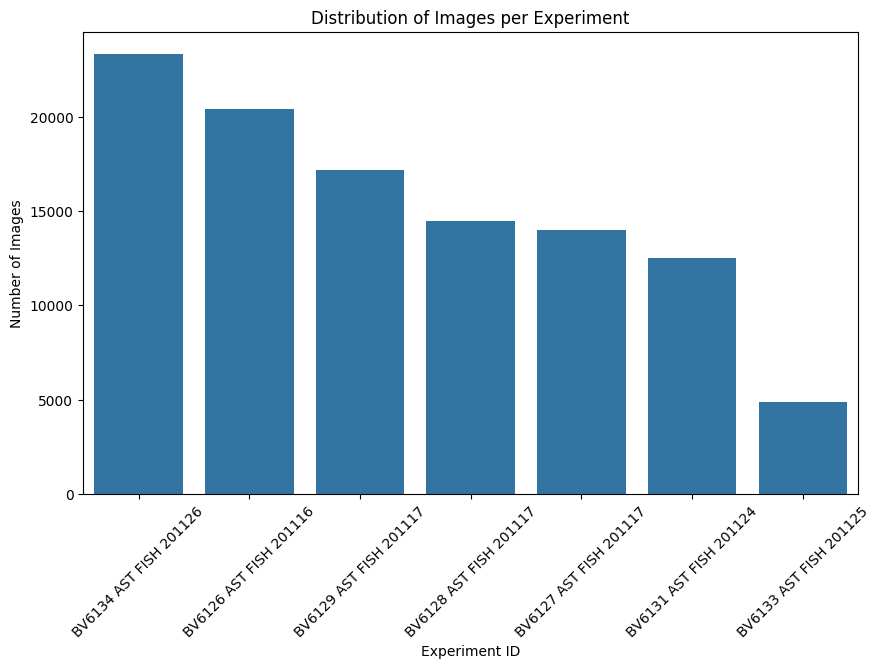

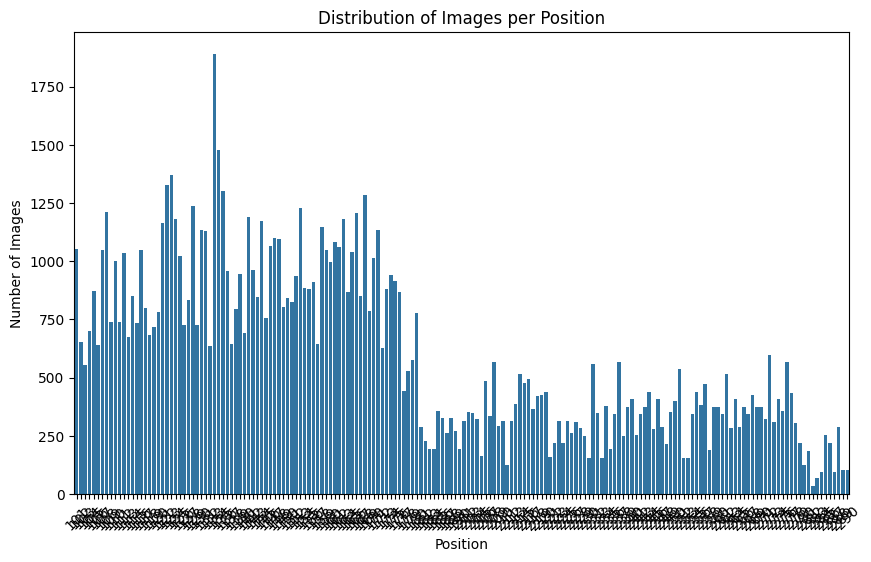

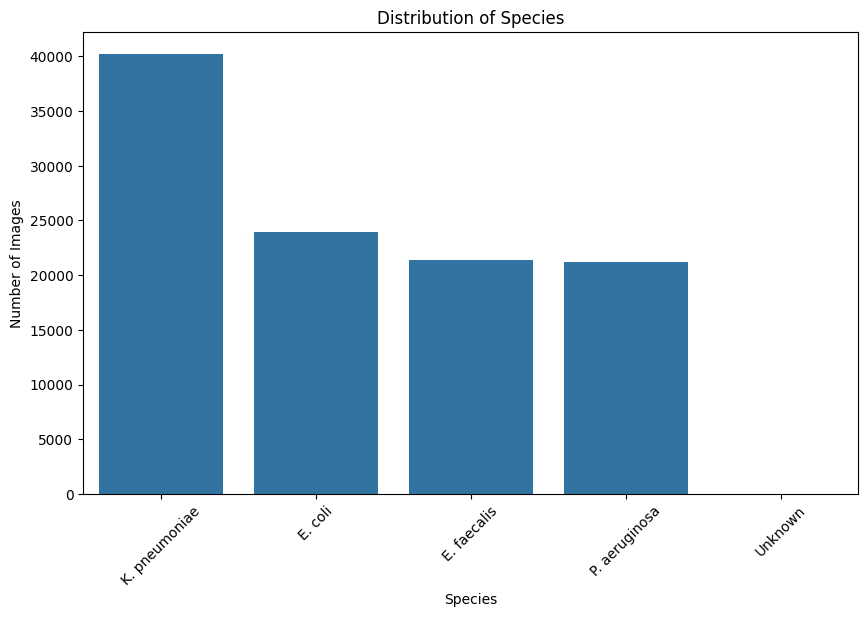

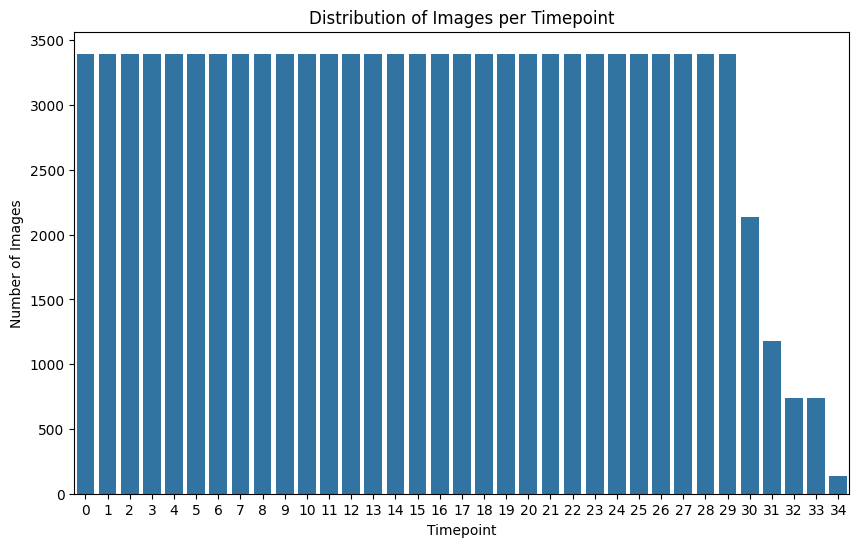

In [14]:
# distribution of images per experiment
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='experiment_id', order=df['experiment_id'].value_counts().index)
plt.title('Distribution of Images per Experiment')
plt.xlabel('Experiment ID')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

# distribution of images per position
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='position', order=df['position'].value_counts().sort_index().index)
plt.title('Distribution of Images per Position')
plt.xlabel('Position')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

# distribution of species
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='species_label', order=df['species_label'].value_counts().index)
plt.title('Distribution of Species')
plt.xlabel('Species')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

# distribution of timepoints
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='timepoint', order=df['timepoint'].value_counts().sort_index().index)
plt.title('Distribution of Images per Timepoint')
plt.xlabel('Timepoint')
plt.ylabel('Number of Images')
plt.show()

In [15]:
df.to_csv('image_metadata.csv', index=False)